# 04 — Prediction of Individual Brain Network Reorganization

This notebook evaluates whether pre-neurofeedback resting-state
functional connectivity can predict individual post-neurofeedback
network reorganization.

The prediction target is the participant-specific connectivity change:

\[
\Delta G = G_{\mathrm{Rest2}} - G_{\mathrm{Rest1}}
\]

Because the current sample is small, prediction begins with
low-dimensional network-level features and regularized models rather
than high-capacity graph neural networks.

## 1 — Prediction Target

The first prediction task evaluates whether baseline Rest1 functional
connectivity can predict the magnitude of subsequent whole-brain
network reorganization.

Predictors:

\[
X = \text{Rest1 network-level connectivity features}
\]

Target:

\[
y = \text{Mean Absolute } \Delta FC
\]

where larger target values indicate greater overall pre-to-post
functional connectivity reorganization.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
from itertools import combinations_with_replacement
from nilearn import datasets

# -----------------------------
# Input directories
# -----------------------------

ZFC_DIR = Path("outputs") / "functional_connectivity_216_fisherz"

# Same 18 QC-passing participants
SUBJECTS = [
    "E3746", "E3799", "E3973", "E4051",
    "E4209", "E4253", "E4324", "E4350",
    "E4360", "E4484", "E4689", "E4697",
    "E4745", "E5215", "E5580", "E5586",
    "E5693", "E5694"
]

# -----------------------------
# Reconstruct network mapping
# -----------------------------

schaefer_info = datasets.fetch_atlas_schaefer_2018(
    n_rois=200,
    yeo_networks=7,
    resolution_mm=2
)

schaefer_labels = schaefer_info.labels[1:]

schaefer_labels = [
    label.decode("utf-8") if isinstance(label, bytes) else str(label)
    for label in schaefer_labels
]

schaefer_networks = [
    label.split("_")[2]
    for label in schaefer_labels
]

roi_networks = (
    schaefer_networks +
    ["Subcortical"] * 16
)

roi_networks_array = np.array(roi_networks)

network_order = [
    "Vis",
    "SomMot",
    "DorsAttn",
    "SalVentAttn",
    "Limbic",
    "Cont",
    "Default",
    "Subcortical"
]

network_pairs = list(
    combinations_with_replacement(
        network_order, 2
    )
)

print("ROIs:", len(roi_networks))
print("Network pairs/features:", len(network_pairs))
print("Participants:", len(SUBJECTS))

[fetch_atlas_schaefer_2018] Dataset directory found: C:\Users\rahin\nilearn_data\schaefer_2018
ROIs: 216
Network pairs/features: 36
Participants: 18


In [4]:
rest1_files = [
    ZFC_DIR / f"{subject}_Rest1_FC_Z_216.csv"
    for subject in SUBJECTS
]

missing_files = [
    str(path)
    for path in rest1_files
    if not path.exists()
]

print("Rest1 files found:", len(rest1_files) - len(missing_files))
print("Expected:", 18)

print("\nMissing files:")
print(missing_files)

Rest1 files found: 18
Expected: 18

Missing files:
[]


In [5]:
feature_rows = []

for subject in SUBJECTS:

    fc_file = ZFC_DIR / f"{subject}_Rest1_FC_Z_216.csv"

    fc = pd.read_csv(
        fc_file,
        index_col=0
    ).to_numpy()

    row = {
        "Subject": subject
    }

    for net1, net2 in network_pairs:

        idx1 = np.where(
            roi_networks_array == net1
        )[0]

        idx2 = np.where(
            roi_networks_array == net2
        )[0]

        block = fc[
            np.ix_(idx1, idx2)
        ].copy()

        # Remove self-connections for within-network features
        if net1 == net2:
            np.fill_diagonal(block, np.nan)

        feature_name = f"{net1}__{net2}"

        row[feature_name] = np.nanmean(block)

    feature_rows.append(row)


X_df = pd.DataFrame(feature_rows)

print("Feature matrix shape:", X_df.shape)
print("Participants:", X_df["Subject"].nunique())
print("Connectivity features:", X_df.shape[1] - 1)

print("\nMissing feature values:")
print(X_df.isna().sum().sum())

display(X_df.head())

Feature matrix shape: (18, 37)
Participants: 18
Connectivity features: 36

Missing feature values:
0


,Subject,Vis__Vis,Vis__SomMot,Vis__DorsAttn,Vis__SalVentAttn,Vis__Limbic,Vis__Cont,Vis__Default,Vis__Subcortical,SomMot__SomMot,...,Limbic__Limbic,Limbic__Cont,Limbic__Default,Limbic__Subcortical,Cont__Cont,Cont__Default,Cont__Subcortical,Default__Default,Default__Subcortical,Subcortical__Subcortical
0,E3746,0.322889,0.260443,0.241302,0.152192,0.138593,0.134564,0.183624,0.097538,0.704435,...,0.217764,0.133452,0.193816,0.132728,0.291311,0.226658,0.095233,0.367744,0.104021,0.321631
1,E3799,0.339104,0.320399,0.216015,0.250969,0.120873,0.109632,0.129929,0.173244,0.626982,...,0.321722,0.156620,0.178082,0.147856,0.288308,0.203744,0.040692,0.294840,0.104985,0.297119
2,E3973,0.495024,0.373328,0.400078,0.290025,0.149804,0.228632,0.222040,0.168943,0.819166,...,0.247413,0.184432,0.226618,0.160105,0.360196,0.325516,0.183708,0.416990,0.220472,0.253143
3,E4051,0.341459,0.166695,0.170213,0.157480,0.063152,0.076611,0.100305,0.104508,0.454429,...,0.207229,0.144673,0.185283,0.147506,0.276197,0.124915,0.093948,0.276270,0.163777,0.330339
4,E4209,0.808644,0.679593,0.668189,0.519240,0.230140,0.396093,0.500405,0.287595,1.060825,...,0.172438,0.186205,0.244277,0.105795,0.537783,0.485413,0.256626,0.601728,0.292197,0.341014


## 2 — Reorganization Target

The prediction target is each participant's magnitude of whole-brain
functional connectivity reorganization.

For each participant, the absolute Fisher-z connectivity change is
averaged across all unique off-diagonal connections:

\[
y_i = \mathrm{mean}\left(|Z_{Rest2,i} - Z_{Rest1,i}|\right)
\]

Higher values indicate greater overall functional network
reorganization between Rest1 and Rest2.

In [7]:
ZDELTA_DIR = Path("outputs") / "delta_connectivity_216_fisherz"

target_rows = []

upper_triangle = np.triu_indices(
    216,
    k=1
)

for subject in SUBJECTS:

    delta_file = (
        ZDELTA_DIR /
        f"{subject}_DeltaFC_Z_216.csv"
    )

    delta = pd.read_csv(
        delta_file,
        index_col=0
    ).to_numpy()

    # Unique off-diagonal connections only
    edge_values = delta[upper_triangle]

    mean_absolute_delta_z = np.nanmean(
        np.abs(edge_values)
    )

    target_rows.append({
        "Subject": subject,
        "Mean_Absolute_DeltaZ": mean_absolute_delta_z
    })


y_df = pd.DataFrame(target_rows)

print("Target participants:", len(y_df))

print("\nMissing target values:")
print(y_df["Mean_Absolute_DeltaZ"].isna().sum())

print("\nTarget summary:")
print(
    y_df["Mean_Absolute_DeltaZ"].describe()
)

display(y_df)

Target participants: 18

Missing target values:
0

Target summary:
count    18.000000
mean      0.157925
std       0.039822
min       0.097877
25%       0.131360
50%       0.146269
75%       0.177584
max       0.257601
Name: Mean_Absolute_DeltaZ, dtype: float64


,Subject,Mean_Absolute_DeltaZ
0,E3746,0.170688
1,E3799,0.228662
2,E3973,0.127891
3,E4051,0.097877
4,E4209,0.257601
5,E4253,0.181969
6,E4324,0.130660
7,E4350,0.123752
8,E4360,0.135896
9,E4484,0.162786


## 3 — Prediction Dataset

Baseline network-level connectivity features are merged with the
participant-specific functional connectivity reorganization target.

Each row represents one participant, with 36 Rest1 network-connectivity
features and one subsequent reorganization target.

In [9]:
prediction_df = X_df.merge(
    y_df,
    on="Subject",
    how="inner"
)

feature_columns = [
    col for col in X_df.columns
    if col != "Subject"
]

X = prediction_df[
    feature_columns
].to_numpy()

y = prediction_df[
    "Mean_Absolute_DeltaZ"
].to_numpy()

print("Participants:", len(prediction_df))
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nMissing X values:", np.isnan(X).sum())
print("Missing y values:", np.isnan(y).sum())

print("\nSubject order:")
print(prediction_df["Subject"].tolist())

Participants: 18
X shape: (18, 36)
y shape: (18,)

Missing X values: 0
Missing y values: 0

Subject order:
['E3746', 'E3799', 'E3973', 'E4051', 'E4209', 'E4253', 'E4324', 'E4350', 'E4360', 'E4484', 'E4689', 'E4697', 'E4745', 'E5215', 'E5580', 'E5586', 'E5693', 'E5694']


## 4 — Ridge Regression Baseline

A regularized linear regression model is used as the initial
prediction baseline because the number of baseline connectivity
features exceeds the number of participants.

Leave-one-out cross-validation (LOOCV) is used so that each
participant is predicted from a model trained only on the remaining
participants.

Feature standardization is performed within each training fold to
avoid information leakage.

In [11]:
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

loo = LeaveOneOut()

y_true = []
y_pred = []

for train_idx, test_idx in loo.split(X):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(
        X_test
    )[0]

    y_true.append(
        y_test[0]
    )

    y_pred.append(
        prediction
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)

mae = mean_absolute_error(
    y_true,
    y_pred
)

r, p = pearsonr(
    y_true,
    y_pred
)

# Baseline: always predict training-sample mean
baseline_predictions = []

for train_idx, test_idx in loo.split(X):
    baseline_predictions.append(
        np.mean(y[train_idx])
    )

baseline_mae = mean_absolute_error(
    y,
    baseline_predictions
)

print("RIDGE LOOCV")
print("MAE:", round(mae, 4))
print("Pearson r:", round(r, 4))
print("Correlation p:", round(p, 4))

print("\nMEAN BASELINE")
print("MAE:", round(baseline_mae, 4))

print("\nImprovement over baseline:",
      round(baseline_mae - mae, 4))

RIDGE LOOCV
MAE: 0.0377
Pearson r: 0.1877
Correlation p: 0.4558

MEAN BASELINE
MAE: 0.033

Improvement over baseline: -0.0048


## 5 — Nested Cross-Validated Ridge Regression

To avoid selecting the regularization parameter using held-out
participants, Ridge regularization strength is selected independently
within each outer leave-one-out training fold.

The outer loop estimates out-of-sample prediction performance, while
the inner cross-validation loop selects the Ridge alpha using only
the training participants.

In [13]:
from sklearn.model_selection import GridSearchCV

outer_loo = LeaveOneOut()

alpha_grid = {
    "ridge__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

nested_true = []
nested_pred = []
selected_alphas = []

for train_idx, test_idx in outer_loo.split(X):

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])

    # Inner LOOCV uses only the 17 training participants
    inner_loo = LeaveOneOut()

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=alpha_grid,
        cv=inner_loo,
        scoring="neg_mean_absolute_error"
    )

    search.fit(
        X_train,
        y_train
    )

    prediction = search.predict(
        X_test
    )[0]

    nested_true.append(
        y_test[0]
    )

    nested_pred.append(
        prediction
    )

    selected_alphas.append(
        search.best_params_["ridge__alpha"]
    )


nested_true = np.array(nested_true)
nested_pred = np.array(nested_pred)

nested_mae = mean_absolute_error(
    nested_true,
    nested_pred
)

nested_r, nested_p = pearsonr(
    nested_true,
    nested_pred
)

print("NESTED RIDGE LOOCV")
print("MAE:", round(nested_mae, 4))
print("Pearson r:", round(nested_r, 4))
print("Correlation p:", round(nested_p, 4))

print("\nMEAN BASELINE")
print("MAE:", round(baseline_mae, 4))

print(
    "\nImprovement over baseline:",
    round(baseline_mae - nested_mae, 4)
)

print("\nSelected alphas:")
print(selected_alphas)

print("\nAlpha frequencies:")
print(
    pd.Series(selected_alphas)
      .value_counts()
      .sort_index()
)

NESTED RIDGE LOOCV
MAE: 0.0359
Pearson r: -0.0891
Correlation p: 0.7253

MEAN BASELINE
MAE: 0.033

Improvement over baseline: -0.0029

Selected alphas:
[100, 10, 10, 1000, 1000, 100, 100, 100, 1000, 100, 100, 100, 10, 100, 10, 10, 10, 100]

Alpha frequencies:
10      6
100     9
1000    3
Name: count, dtype: int64


In [14]:
prediction_results = pd.DataFrame({
    "Subject": prediction_df["Subject"],
    "Observed_DeltaZ": nested_true,
    "Predicted_DeltaZ": nested_pred,
    "Residual": nested_true - nested_pred,
    "Selected_Alpha": selected_alphas
})

display(prediction_results)

print("\nObserved mean:",
      round(prediction_results["Observed_DeltaZ"].mean(), 4))

print("Predicted mean:",
      round(prediction_results["Predicted_DeltaZ"].mean(), 4))

print("Largest absolute prediction error:")
display(
    prediction_results
    .assign(
        Absolute_Error=lambda x: np.abs(x["Residual"])
    )
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(5)
)

,Subject,Observed_DeltaZ,Predicted_DeltaZ,Residual,Selected_Alpha
0,E3746,0.170688,0.150243,0.020445,100
1,E3799,0.228662,0.133475,0.095187,10
2,E3973,0.127891,0.180772,-0.052881,10
3,E4051,0.097877,0.155588,-0.057712,1000
4,E4209,0.257601,0.160401,0.097201,1000
5,E4253,0.181969,0.205956,-0.023987,100
6,E4324,0.130660,0.142578,-0.011918,100
7,E4350,0.123752,0.150251,-0.026499,100
8,E4360,0.135896,0.151809,-0.015913,1000
9,E4484,0.162786,0.146412,0.016374,100



Observed mean: 0.1579
Predicted mean: 0.157
Largest absolute prediction error:


,Subject,Observed_DeltaZ,Predicted_DeltaZ,Residual,Selected_Alpha,Absolute_Error
4,E4209,0.257601,0.160401,0.097201,1000,0.097201
1,E3799,0.228662,0.133475,0.095187,10,0.095187
3,E4051,0.097877,0.155588,-0.057712,1000,0.057712
15,E5586,0.178291,0.124278,0.054013,10,0.054013
2,E3973,0.127891,0.180772,-0.052881,10,0.052881


## 6 — Network-Specific Reorganization Targets

Whole-brain mean absolute change compresses each participant's
reorganization into a single scalar and may discard information about
the spatial pattern of network change.

Therefore, a second analysis represents each participant's
Rest1-to-Rest2 transition using 36 within- and between-network
connectivity changes.

For each network pair:

\[
\Delta Z_{ab} = Z_{Rest2,ab} - Z_{Rest1,ab}
\]

This produces a 36-dimensional network-reorganization profile for
each participant.

In [16]:
delta_feature_rows = []

for subject in SUBJECTS:

    delta_file = (
        ZDELTA_DIR /
        f"{subject}_DeltaFC_Z_216.csv"
    )

    delta = pd.read_csv(
        delta_file,
        index_col=0
    ).to_numpy()

    row = {
        "Subject": subject
    }

    for net1, net2 in network_pairs:

        idx1 = np.where(
            roi_networks_array == net1
        )[0]

        idx2 = np.where(
            roi_networks_array == net2
        )[0]

        block = delta[
            np.ix_(idx1, idx2)
        ].copy()

        if net1 == net2:
            np.fill_diagonal(
                block,
                np.nan
            )

        feature_name = (
            f"Delta_{net1}__{net2}"
        )

        row[feature_name] = np.nanmean(
            block
        )

    delta_feature_rows.append(row)


delta_network_df = pd.DataFrame(
    delta_feature_rows
)

print(
    "Delta network matrix shape:",
    delta_network_df.shape
)

print(
    "Participants:",
    delta_network_df["Subject"].nunique()
)

print(
    "Network-change features:",
    delta_network_df.shape[1] - 1
)

print(
    "Missing values:",
    delta_network_df.isna().sum().sum()
)

display(delta_network_df.head())

Delta network matrix shape: (18, 37)
Participants: 18
Network-change features: 36
Missing values: 0


,Subject,Delta_Vis__Vis,Delta_Vis__SomMot,Delta_Vis__DorsAttn,Delta_Vis__SalVentAttn,Delta_Vis__Limbic,Delta_Vis__Cont,Delta_Vis__Default,Delta_Vis__Subcortical,Delta_SomMot__SomMot,...,Delta_Limbic__Limbic,Delta_Limbic__Cont,Delta_Limbic__Default,Delta_Limbic__Subcortical,Delta_Cont__Cont,Delta_Cont__Default,Delta_Cont__Subcortical,Delta_Default__Default,Delta_Default__Subcortical,Delta_Subcortical__Subcortical
0,E3746,0.061024,0.086629,0.105805,0.115635,0.051745,0.033472,0.073070,0.039567,0.103876,...,-0.040550,0.002751,0.062868,-0.027318,0.003731,0.057548,-0.015056,0.121430,0.028267,0.053371
1,E3799,0.246844,0.121269,0.259492,0.193565,0.168183,0.277158,0.195970,0.113664,0.071823,...,-0.008720,0.077563,0.077281,0.101940,0.247052,0.196466,0.214830,0.146520,0.143805,0.084911
2,E3973,0.007481,0.009383,0.095266,0.033601,0.059886,0.104500,0.091367,0.003652,0.095023,...,-0.073589,0.021848,-0.016292,-0.028323,0.097785,0.075588,-0.004720,0.039496,-0.013938,0.043429
3,E4051,0.047097,0.010883,0.025943,-0.009918,0.019226,0.002487,-0.016371,0.017490,-0.060051,...,0.008936,0.003164,0.039302,-0.005875,-0.011669,0.048254,0.017591,0.035828,-0.025506,-0.043495
4,E4209,-0.391996,-0.317622,-0.330128,-0.265370,-0.148227,-0.111184,-0.265464,-0.138196,-0.268203,...,-0.071397,-0.082580,-0.117313,-0.046833,-0.132162,-0.203485,-0.089342,-0.242713,-0.105753,-0.042134


## 7 — Dimensionality of Network Reorganization

The 36 network-level connectivity changes are highly multivariate
relative to the sample size. Principal component analysis (PCA) is
first used descriptively to determine whether individual
reorganization profiles can be represented by a smaller number of
dominant transition patterns.

This descriptive analysis is not used to estimate predictive
performance. PCA used for prediction will subsequently be fitted
within cross-validation folds to avoid information leakage.

Y_delta shape: (18, 36)

Variance explained:
PC1: 0.670 (cumulative 0.670)
PC2: 0.107 (cumulative 0.777)
PC3: 0.060 (cumulative 0.837)
PC4: 0.031 (cumulative 0.868)
PC5: 0.029 (cumulative 0.897)
PC6: 0.021 (cumulative 0.918)
PC7: 0.018 (cumulative 0.936)
PC8: 0.013 (cumulative 0.949)
PC9: 0.012 (cumulative 0.962)
PC10: 0.011 (cumulative 0.973)

Components needed for 80% variance: 3
Components needed for 90% variance: 6


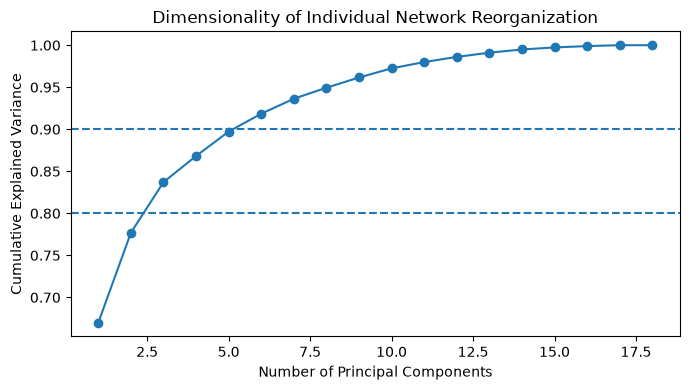

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

Y_delta = (
    delta_network_df
    .drop(columns="Subject")
    .to_numpy()
)

pca = PCA()
pca.fit(Y_delta)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

print("Y_delta shape:", Y_delta.shape)

print("\nVariance explained:")
for i in range(min(10, len(explained))):
    print(
        f"PC{i+1}: "
        f"{explained[i]:.3f} "
        f"(cumulative {cumulative[i]:.3f})"
    )

print(
    "\nComponents needed for 80% variance:",
    np.argmax(cumulative >= 0.80) + 1
)

print(
    "Components needed for 90% variance:",
    np.argmax(cumulative >= 0.90) + 1
)

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.axhline(
    0.80,
    linestyle="--"
)

plt.axhline(
    0.90,
    linestyle="--"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title(
    "Dimensionality of Individual Network Reorganization"
)

plt.tight_layout()
plt.show()

## 8 — Dominant Reorganization Pattern

PC1 explains the largest proportion of variance in individual
network-reorganization profiles. Its loadings are examined to
determine which within- and between-network connectivity changes
contribute most strongly to this dominant transition pattern.

In [20]:
delta_feature_names = (
    delta_network_df
    .drop(columns="Subject")
    .columns
)

pc1_loadings = pd.DataFrame({
    "Feature": delta_feature_names,
    "PC1_Loading": pca.components_[0]
})

pc1_loadings["Absolute_Loading"] = (
    pc1_loadings["PC1_Loading"].abs()
)

pc1_loadings = (
    pc1_loadings
    .sort_values(
        "Absolute_Loading",
        ascending=False
    )
)

print(
    "PC1 variance explained:",
    round(explained[0], 3)
)

print("\nTop 15 PC1 loadings:")

display(
    pc1_loadings.head(15)
)

PC1 variance explained: 0.67

Top 15 PC1 loadings:


,Feature,PC1_Loading,Absolute_Loading
2,Delta_Vis__DorsAttn,0.241667,0.241667
0,Delta_Vis__Vis,0.236274,0.236274
9,Delta_SomMot__DorsAttn,0.233391,0.233391
19,Delta_DorsAttn__Default,0.218892,0.218892
15,Delta_DorsAttn__DorsAttn,0.214160,0.214160
16,Delta_DorsAttn__SalVentAttn,0.212786,0.212786
6,Delta_Vis__Default,0.208509,0.208509
23,Delta_SalVentAttn__Cont,0.208078,0.208078
24,Delta_SalVentAttn__Default,0.203391,0.203391
8,Delta_SomMot__SomMot,0.199384,0.199384


In [21]:
print("Positive PC1 loadings:",
      (pca.components_[0] > 0).sum())

print("Negative PC1 loadings:",
      (pca.components_[0] < 0).sum())

print("\nPC1 loading range:")
print(
    "Minimum:",
    round(pca.components_[0].min(), 4)
)
print(
    "Maximum:",
    round(pca.components_[0].max(), 4)
)

print("\nLowest 10 PC1 loadings:")

display(
    pd.DataFrame({
        "Feature": delta_feature_names,
        "PC1_Loading": pca.components_[0]
    })
    .sort_values("PC1_Loading")
    .head(10)
)

Positive PC1 loadings: 36
Negative PC1 loadings: 0

PC1 loading range:
Minimum: 0.0182
Maximum: 0.2417

Lowest 10 PC1 loadings:


,Feature,PC1_Loading
26,Delta_Limbic__Limbic,0.018163
29,Delta_Limbic__Subcortical,0.044512
27,Delta_Limbic__Cont,0.064199
28,Delta_Limbic__Default,0.066579
35,Delta_Subcortical__Subcortical,0.083650
17,Delta_DorsAttn__Limbic,0.085285
34,Delta_Default__Subcortical,0.115628
11,Delta_SomMot__Limbic,0.118765
22,Delta_SalVentAttn__Limbic,0.119269
14,Delta_SomMot__Subcortical,0.124445


## 9 — Individual Dominant Transition Scores

Each participant is projected onto the dominant reorganization
component (PC1). Positive and negative scores represent opposite
directions along the distributed whole-brain connectivity transition
axis.

In [23]:
pca_scores = pca.transform(Y_delta)

pc1_scores_df = pd.DataFrame({
    "Subject": delta_network_df["Subject"],
    "PC1_Score": pca_scores[:, 0]
})

pc1_scores_df = (
    pc1_scores_df
    .sort_values(
        "PC1_Score",
        ascending=False
    )
)

display(pc1_scores_df)

print("\nPC1 score summary:")
print(
    pc1_scores_df["PC1_Score"].describe()
)

print(
    "\nPositive scores:",
    (pc1_scores_df["PC1_Score"] > 0).sum()
)

print(
    "Negative scores:",
    (pc1_scores_df["PC1_Score"] < 0).sum()
)

,Subject,PC1_Score
1,E3799,1.177016
0,E3746,0.677521
14,E5580,0.394335
2,E3973,0.292400
7,E4350,0.239228
17,E5694,0.209184
8,E4360,0.158513
9,E4484,0.097306
3,E4051,0.066271
11,E4697,0.028252



PC1 score summary:
count    1.800000e+01
mean     3.700743e-17
std      5.145638e-01
min     -1.077145e+00
25%     -2.866994e-01
50%      4.726155e-02
75%      2.317168e-01
max      1.177016e+00
Name: PC1_Score, dtype: float64

Positive scores: 10
Negative scores: 8


## 10 — Dominant Transition Pattern by Neurofeedback Group

Before using the dominant transition score as a prediction target,
its relationship with intervention group is examined.

This determines whether the dominant Rest1-to-Rest2 connectivity
transition primarily reflects treatment-group differences or
individual variability across participants.

In [25]:
PARTICIPANTS_FILE = Path(
    r"C:\Neurofeedback_Data_Fall26\Imaging\Processed Rest1&2 Scans\participants.tsv"
)

participants = pd.read_csv(
    PARTICIPANTS_FILE,
    sep="\t"
)

print("Participants file loaded:", PARTICIPANTS_FILE.exists())
print("Shape:", participants.shape)
print("Exam column exists:", "Exam" in participants.columns)
print("Group column exists:", "Group" in participants.columns)

Participants file loaded: True
Shape: (355, 27)
Exam column exists: True
Group column exists: True


In [26]:
# Get one group label per participant
group_df = (
    participants[
        ["Exam", "Group"]
    ]
    .drop_duplicates("Exam")
    .rename(columns={"Exam": "Subject"})
)

pc1_group_df = (
    pc1_scores_df
    .merge(
        group_df,
        on="Subject",
        how="left"
    )
)

print("Missing group labels:",
      pc1_group_df["Group"].isna().sum())

print("\nGroup counts:")
print(
    pc1_group_df["Group"].value_counts()
)

print("\nPC1 by group:")
print(
    pc1_group_df
    .groupby("Group")["PC1_Score"]
    .agg(["count", "mean", "std"])
)

Missing group labels: 0

Group counts:
Group
active    10
sham       8
Name: count, dtype: int64

PC1 by group:
        count      mean       std
Group                            
active     10  0.126304  0.493566
sham        8 -0.157880  0.527769


In [27]:
from scipy.stats import ttest_ind

active_pc1 = (
    pc1_group_df.loc[
        pc1_group_df["Group"] == "active",
        "PC1_Score"
    ].to_numpy()
)

sham_pc1 = (
    pc1_group_df.loc[
        pc1_group_df["Group"] == "sham",
        "PC1_Score"
    ].to_numpy()
)

# Welch independent-samples t-test
t_stat, p_value = ttest_ind(
    active_pc1,
    sham_pc1,
    equal_var=False
)

# Cohen's d
n1 = len(active_pc1)
n2 = len(sham_pc1)

s1 = np.std(active_pc1, ddof=1)
s2 = np.std(sham_pc1, ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * s1**2 +
     (n2 - 1) * s2**2)
    /
    (n1 + n2 - 2)
)

cohens_d = (
    np.mean(active_pc1) -
    np.mean(sham_pc1)
) / pooled_sd

print("PC1 GROUP COMPARISON")

print("\nActive")
print("n:", n1)
print("Mean:", round(np.mean(active_pc1), 4))
print("SD:", round(s1, 4))

print("\nSham")
print("n:", n2)
print("Mean:", round(np.mean(sham_pc1), 4))
print("SD:", round(s2, 4))

print("\nActive - Sham difference:",
      round(
          np.mean(active_pc1) -
          np.mean(sham_pc1),
          4
      ))

print("Welch t:", round(t_stat, 4))
print("p-value:", round(p_value, 4))
print("Cohen's d:", round(cohens_d, 4))

PC1 GROUP COMPARISON

Active
n: 10
Mean: 0.1263
SD: 0.4936

Sham
n: 8
Mean: -0.1579
SD: 0.5278

Active - Sham difference: 0.2842
Welch t: 1.1682
p-value: 0.2614
Cohen's d: 0.5585


## 11 — Intervention-Aware Predictors

Because post-neurofeedback brain-state transitions may depend on both
baseline network organization and the intervention received,
neurofeedback group is incorporated as an additional predictor.

The resulting formulation is:

\[
f(G_{\mathrm{Rest1}}, I) \rightarrow \Delta G
\]

where \(G_{\mathrm{Rest1}}\) represents baseline network organization
and \(I\) represents active versus sham neurofeedback.

In [29]:
group_lookup = (
    pc1_group_df[
        ["Subject", "Group"]
    ]
    .drop_duplicates("Subject")
)

prediction_group_df = (
    prediction_df
    .merge(
        group_lookup,
        on="Subject",
        how="left"
    )
)

# Binary intervention indicator
prediction_group_df["Active"] = (
    prediction_group_df["Group"]
    .eq("active")
    .astype(int)
)

X_group = prediction_group_df[
    feature_columns + ["Active"]
].to_numpy()

print("Participants:", len(prediction_group_df))
print("Baseline FC features:", len(feature_columns))
print("Intervention features: 1")
print("X_group shape:", X_group.shape)

print("\nGroup coding:")
print(
    prediction_group_df[
        ["Subject", "Group", "Active"]
    ]
)

print(
    "\nMissing predictor values:",
    np.isnan(X_group).sum()
)

Participants: 18
Baseline FC features: 36
Intervention features: 1
X_group shape: (18, 37)

Group coding:
   Subject   Group  Active
0    E3746  active       1
1    E3799  active       1
2    E3973    sham       0
3    E4051    sham       0
4    E4209    sham       0
5    E4253    sham       0
6    E4324  active       1
7    E4350  active       1
8    E4360  active       1
9    E4484  active       1
10   E4689  active       1
11   E4697    sham       0
12   E4745  active       1
13   E5215  active       1
14   E5580    sham       0
15   E5586    sham       0
16   E5693  active       1
17   E5694    sham       0

Missing predictor values: 0


## 12 — Leakage-Free Prediction of the Dominant Brain-State Transition

Prediction of the dominant network-reorganization pattern is evaluated
using an outer leave-one-out procedure.

For each held-out participant, PCA is fitted exclusively to the
reorganization profiles of the remaining participants. The held-out
participant is then projected onto the training-derived dominant
transition axis.

This prevents the held-out participant from contributing to the
definition of the prediction target.

Because PCA component signs are arbitrary, the first component is
oriented consistently so that its mean loading is positive.

In [31]:
from sklearn.decomposition import PCA

outer_loo = LeaveOneOut()

transition_true = []
transition_pred = []
transition_subjects = []
transition_alphas = []

for train_idx, test_idx in outer_loo.split(X_group):

    # -----------------------------
    # Predictor data
    # -----------------------------
    X_train = X_group[train_idx]
    X_test = X_group[test_idx]

    # -----------------------------
    # Reorganization profiles
    # -----------------------------
    Y_train = Y_delta[train_idx]
    Y_test = Y_delta[test_idx]

    # -----------------------------
    # PCA fitted ONLY on training participants
    # -----------------------------
    target_pca = PCA(n_components=1)

    train_scores = target_pca.fit_transform(
        Y_train
    ).ravel()

    test_score = target_pca.transform(
        Y_test
    ).ravel()[0]

    # Orient PC1 consistently
    if target_pca.components_[0].mean() < 0:
        train_scores *= -1
        test_score *= -1

    # -----------------------------
    # Ridge model
    # -----------------------------
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])

    inner_loo = LeaveOneOut()

    search = GridSearchCV(
        pipeline,
        param_grid=alpha_grid,
        cv=inner_loo,
        scoring="neg_mean_absolute_error"
    )

    search.fit(
        X_train,
        train_scores
    )

    predicted_score = search.predict(
        X_test
    )[0]

    transition_true.append(
        test_score
    )

    transition_pred.append(
        predicted_score
    )

    transition_subjects.append(
        prediction_group_df.iloc[
            test_idx[0]
        ]["Subject"]
    )

    transition_alphas.append(
        search.best_params_["ridge__alpha"]
    )


transition_true = np.array(
    transition_true
)

transition_pred = np.array(
    transition_pred
)

transition_mae = mean_absolute_error(
    transition_true,
    transition_pred
)

transition_r, transition_p = pearsonr(
    transition_true,
    transition_pred
)

print(
    "LEAKAGE-FREE DOMINANT TRANSITION PREDICTION"
)

print(
    "\nMAE:",
    round(transition_mae, 4)
)

print(
    "Pearson r:",
    round(transition_r, 4)
)

print(
    "Correlation p:",
    round(transition_p, 4)
)

print("\nSelected alpha frequencies:")

print(
    pd.Series(
        transition_alphas
    )
    .value_counts()
    .sort_index()
)

LEAKAGE-FREE DOMINANT TRANSITION PREDICTION

MAE: 0.368
Pearson r: 0.3923
Correlation p: 0.1074

Selected alpha frequencies:
0.01       1
1.00       1
100.00    16
Name: count, dtype: int64


In [32]:
baseline_transition_true = []
baseline_transition_pred = []

for train_idx, test_idx in outer_loo.split(X_group):

    Y_train = Y_delta[train_idx]
    Y_test = Y_delta[test_idx]

    fold_pca = PCA(n_components=1)

    train_scores = fold_pca.fit_transform(
        Y_train
    ).ravel()

    test_score = fold_pca.transform(
        Y_test
    ).ravel()[0]

    # Same orientation rule
    if fold_pca.components_[0].mean() < 0:
        train_scores *= -1
        test_score *= -1

    baseline_prediction = np.mean(
        train_scores
    )

    baseline_transition_true.append(
        test_score
    )

    baseline_transition_pred.append(
        baseline_prediction
    )


baseline_transition_true = np.array(
    baseline_transition_true
)

baseline_transition_pred = np.array(
    baseline_transition_pred
)

baseline_transition_mae = mean_absolute_error(
    baseline_transition_true,
    baseline_transition_pred
)

print("DOMINANT TRANSITION BASELINE")

print(
    "\nBaseline MAE:",
    round(baseline_transition_mae, 4)
)

print(
    "Ridge MAE:",
    round(transition_mae, 4)
)

print(
    "\nMAE improvement:",
    round(
        baseline_transition_mae -
        transition_mae,
        4
    )
)

print(
    "Percent MAE improvement:",
    round(
        (
            baseline_transition_mae -
            transition_mae
        )
        /
        baseline_transition_mae
        * 100,
        2
    ),
    "%"
)

DOMINANT TRANSITION BASELINE

Baseline MAE: 0.3773
Ridge MAE: 0.368

MAE improvement: 0.0093
Percent MAE improvement: 2.47 %


## 13 — Contribution of Intervention Information

To determine whether intervention assignment contributes predictive
information beyond baseline brain organization, the leakage-free
dominant-transition model is repeated using baseline Rest1
connectivity features alone.

Performance is compared with the intervention-aware model.

In [34]:
connectivity_true = []
connectivity_pred = []
connectivity_alphas = []

for train_idx, test_idx in outer_loo.split(X):

    X_train = X[train_idx]
    X_test = X[test_idx]

    Y_train = Y_delta[train_idx]
    Y_test = Y_delta[test_idx]

    # PCA fitted only on training participants
    fold_pca = PCA(n_components=1)

    train_scores = fold_pca.fit_transform(
        Y_train
    ).ravel()

    test_score = fold_pca.transform(
        Y_test
    ).ravel()[0]

    # Consistent orientation
    if fold_pca.components_[0].mean() < 0:
        train_scores *= -1
        test_score *= -1

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])

    search = GridSearchCV(
        pipeline,
        param_grid=alpha_grid,
        cv=LeaveOneOut(),
        scoring="neg_mean_absolute_error"
    )

    search.fit(
        X_train,
        train_scores
    )

    prediction = search.predict(
        X_test
    )[0]

    connectivity_true.append(
        test_score
    )

    connectivity_pred.append(
        prediction
    )

    connectivity_alphas.append(
        search.best_params_["ridge__alpha"]
    )


connectivity_true = np.array(
    connectivity_true
)

connectivity_pred = np.array(
    connectivity_pred
)

connectivity_mae = mean_absolute_error(
    connectivity_true,
    connectivity_pred
)

connectivity_r, connectivity_p = pearsonr(
    connectivity_true,
    connectivity_pred
)

print("CONNECTIVITY-ONLY MODEL")

print(
    "\nMAE:",
    round(connectivity_mae, 4)
)

print(
    "Pearson r:",
    round(connectivity_r, 4)
)

print(
    "Correlation p:",
    round(connectivity_p, 4)
)

print("\nINTERVENTION-AWARE MODEL")

print(
    "MAE:",
    round(transition_mae, 4)
)

print(
    "Pearson r:",
    round(transition_r, 4)
)

print(
    "\nMAE difference:",
    round(
        connectivity_mae -
        transition_mae,
        4
    )
)

CONNECTIVITY-ONLY MODEL

MAE: 0.3691
Pearson r: 0.3814
Correlation p: 0.1184

INTERVENTION-AWARE MODEL
MAE: 0.368
Pearson r: 0.3923

MAE difference: 0.0011


## 14 — Permutation-Based Validation

Permutation testing was used to determine whether the observed
out-of-sample prediction performance exceeded that expected under
the null hypothesis of no relationship between baseline connectivity
and subsequent network reorganization.

For each permutation, participant reorganization profiles were
randomly reassigned relative to baseline connectivity. The complete
leakage-free prediction procedure, including training-fold PCA and
regularized regression, was then repeated.

The permutation p-value represents the proportion of null prediction
correlations equal to or greater than the observed out-of-sample
correlation.

In [36]:
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA
from scipy.stats import pearsonr
import numpy as np

# --------------------------------------------------
# Observed connectivity-only prediction correlation
# --------------------------------------------------

observed_r = connectivity_r

print(
    "Observed prediction r:",
    round(observed_r, 4)
)

# --------------------------------------------------
# Permutation settings
# --------------------------------------------------

N_PERMUTATIONS = 1000
rng = np.random.default_rng(42)

permutation_r = []

outer_loo = LeaveOneOut()

# --------------------------------------------------
# Permutation loop
# --------------------------------------------------

for perm in range(N_PERMUTATIONS):

    # Break participant-level correspondence between
    # baseline connectivity and subsequent reorganization
    permuted_indices = rng.permutation(
        len(Y_delta)
    )

    Y_perm = Y_delta[
        permuted_indices
    ]

    perm_true = []
    perm_pred = []

    for train_idx, test_idx in outer_loo.split(X):

        X_train = X[train_idx]
        X_test = X[test_idx]

        Y_train = Y_perm[train_idx]
        Y_test = Y_perm[test_idx]

        # ------------------------------------------
        # Define transition axis using training data only
        # ------------------------------------------

        fold_pca = PCA(
            n_components=1
        )

        train_scores = (
            fold_pca
            .fit_transform(Y_train)
            .ravel()
        )

        test_score = (
            fold_pca
            .transform(Y_test)
            .ravel()[0]
        )

        # Consistent PC1 orientation
        if fold_pca.components_[0].mean() < 0:
            train_scores *= -1
            test_score *= -1

        # ------------------------------------------
        # Nested Ridge model
        # ------------------------------------------

        pipeline = Pipeline([
            (
                "scaler",
                StandardScaler()
            ),
            (
                "ridge",
                Ridge()
            )
        ])

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=alpha_grid,
            cv=LeaveOneOut(),
            scoring="neg_mean_absolute_error"
        )

        search.fit(
            X_train,
            train_scores
        )

        prediction = search.predict(
            X_test
        )[0]

        perm_true.append(
            test_score
        )

        perm_pred.append(
            prediction
        )

    perm_true = np.array(
        perm_true
    )

    perm_pred = np.array(
        perm_pred
    )

    r_perm, _ = pearsonr(
        perm_true,
        perm_pred
    )

    permutation_r.append(
        r_perm
    )

    # Progress indicator
    if (perm + 1) % 100 == 0:
        print(
            f"Completed {perm + 1} / "
            f"{N_PERMUTATIONS}"
        )


permutation_r = np.array(
    permutation_r
)

# --------------------------------------------------
# One-sided permutation p-value
# --------------------------------------------------

permutation_p = (
    np.sum(
        permutation_r >= observed_r
    ) + 1
) / (
    N_PERMUTATIONS + 1
)

print(
    "\nPERMUTATION TEST"
)

print(
    "Observed r:",
    round(observed_r, 4)
)

print(
    "Null mean r:",
    round(
        np.mean(permutation_r),
        4
    )
)

print(
    "Null SD:",
    round(
        np.std(
            permutation_r,
            ddof=1
        ),
        4
    )
)

print(
    "Permutation p-value:",
    round(permutation_p, 4)
)

print(
    "Null correlations >= observed:",
    np.sum(
        permutation_r >= observed_r
    )
)

Observed prediction r: 0.3814
Completed 100 / 1000
Completed 200 / 1000
Completed 300 / 1000
Completed 400 / 1000
Completed 900 / 1000
Completed 1000 / 1000

PERMUTATION TEST
Observed r: 0.3814
Null mean r: -0.1189
Null SD: 0.2788
Permutation p-value: 0.046
Null correlations >= observed: 45


### Permutation-Test Interpretation

The connectivity-only model achieved an out-of-sample correlation of
r = 0.381 between predicted and observed dominant transition scores.

Permutation testing (1,000 permutations) produced a null mean
correlation of -0.119. Only 45 of 1,000 permutations produced a
correlation equal to or greater than the observed value, corresponding
to a permutation p-value of 0.046.

These results provide evidence that baseline resting-state connectivity
contains predictive information about the dominant direction of
subsequent network reorganization beyond that expected from random
participant correspondence. However, the predictive effect was modest,
and improvement in MAE relative to the baseline predictor was small.
Given the limited sample size, the result should be interpreted as
preliminary rather than as evidence of a clinically validated
predictive biomarker.